Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Carga imagen desde archivo con OpenCV y convierte a RGB

(512, 512, 3)


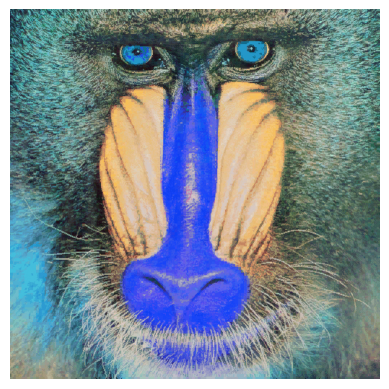

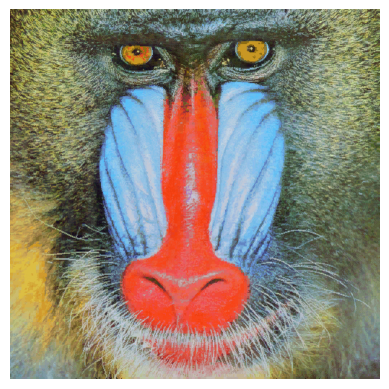

In [ ]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg') 

#Si hay lectura correcta
if img is not None:
    #Muestra dimensiones
    print(img.shape)
    #Muestra la imagen original con matplotlib
    plt.figure()
    #Elimina etiquetas de los ejes que muestra matplotlib
    plt.axis("off")
    plt.imshow(img) 
    plt.show()

    #Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizar de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Muestra la imagen tras convertir a RGB
    #Eliminamos etiquetas de los ejes
    plt.figure()
    plt.axis("off")
    plt.imshow(img_rgb) 
    plt.show()
else: 
    print('Imagen no encontrada')

Escribe un texto en una posición de la imagen

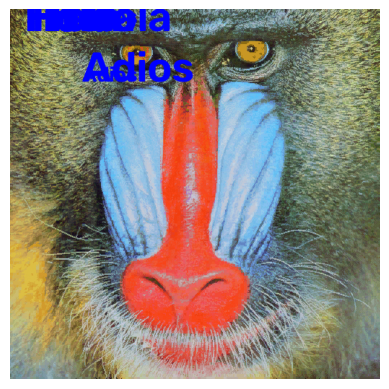

In [ ]:
# Define tipografías (Bastante limitadas en OpenCV)
font = cv2.FONT_HERSHEY_SIMPLEX
    
# Define parámetros del texto
position=(100,100)
font_scale=2.0
color=(0, 0, 255)
thickness=2
# Añade texto a la imagen
cv2.putText(img_rgb, "Adios", position, font, font_scale, color, thickness)

plt.figure()
plt.axis("off")
plt.imshow(img_rgb) 
plt.show()

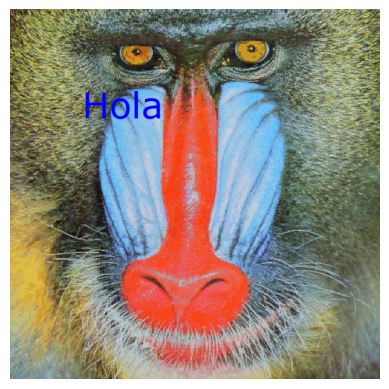

In [33]:
#Para más tipografías, usar PIL como alternativa
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Conversión de numpy array a PIL Image (tener presente que debe ser RGB, por ello la conversión previa)
pil_image = Image.fromarray(img_rgb) 
#Crea objeto para dibujar
draw = ImageDraw.Draw(pil_image)

# Carga tipografía (puede haber errores) y define parámetros
position=(100,100)
font_size=50.0
color=(0, 0, 255)
#Tipografías en Windows
#font = ImageFont.truetype("arial.ttf", font_size)
#font = ImageFont.truetype("times.ttf", font_size)
font = ImageFont.truetype("verdana.ttf", font_size)
#font = ImageFont.truetype("tahoma.ttf", font_size)

# Añade texto a la imagen
draw.text(position, "Hola", fill=color, font=font)

# Convierte resultado a numpy array para matplotlib
final_img_rgb = np.array(pil_image)

plt.figure()
plt.axis("off")
plt.imshow(final_img_rgb) 
plt.show()

Convierte la imagen a grises para procesamiento posterior

(512, 512)


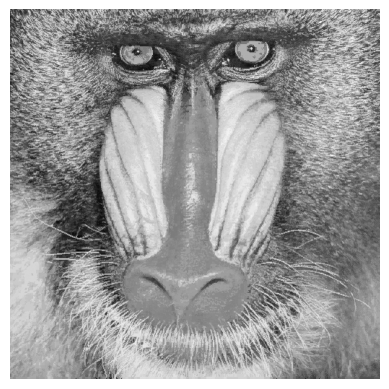

In [ ]:
#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)
#Muestra, indicando el mapa de color de grises con matplotlib
plt.figure()
#Eliminamos etiquetas de los ejes
plt.axis("off")
#Muestra la imagen en grises
plt.imshow(gris, cmap='gray') 
plt.show()


Canny, detector de contornos multietapa. Descrito en mayor detalle en las sesiones de teoría (tema 4)

[[  0 255   0 ...   0   0   0]
 [  0 255   0 ... 255   0   0]
 [255   0   0 ...   0 255 255]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


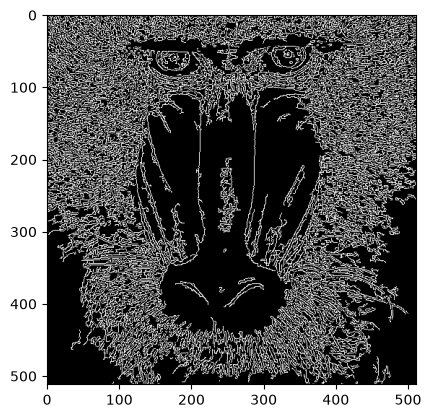

In [12]:
#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 64, 224) #prueba a jugar con umbrales (entre 0 y 255)
print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()


Cuenta el número de píxeles no nulos por columna y visualiza el vector resultante

[[  0 255   0 ...   0   0   0]
 [  0 255   0 ... 255   0   0]
 [255   0   0 ...   0 255 255]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
[[22440 25245 24480 26520 25500 23460 24225 26010 27030 24225 25245 21420
  24990 26775 20145 23970 24990 23715 26010 26520 24480 25500 26265 28050
  31110 25500 29325 31110 25755 25755 24990 28560 31365 29835 24990 32385
  30090 29835 26265 29580 29325 26520 28305 28560 29070 25500 31110 32385
  29325 31365 28815 33150 32385 34680 33915 35445 38760 34935 37485 39525
  39270 39780 36210 40035 42840 34170 33405 45135 41310 37230 40545 39525
  41310 37485 33150 37740 39015 36210 35190 39525 40290 36210 36465 41055
  42330 41820 43350 38505 41310 39015 41565 40035 45390 36720 41820 34680
  43095 40545 38250 45390 44625 37740 42075 44115 47685 43350 38760 42330
  40800 41310 40290 39015 45135 39270 39015 46920 40290 37740 40290 47175
  36465 37485 36210 43350 41055 40800 37230 41055 34170 39015 40290 

(0.0, 512.0)

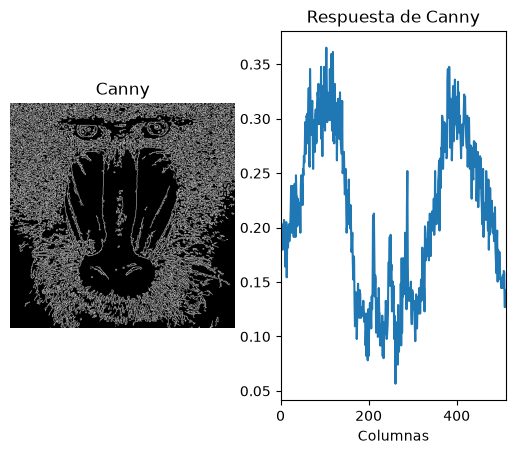

In [ ]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
print(col_counts)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * canny.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

## TAREA 1
- Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Fila @ 90%:   6 	Valor:  [0.390625]
Fila @ 90%:   15 	Valor:  [0.40429688]
Fila @ 90%:   20 	Valor:  [0.39453125]
Fila @ 90%:   21 	Valor:  [0.40039062]
Fila @ 90%:   88 	Valor:  [0.39453125]
Fila @ 90%:   98 	Valor:  [0.39257812]
Fila @ 90%:   100 	Valor:  [0.4140625]
512


(0.0, 512.0)

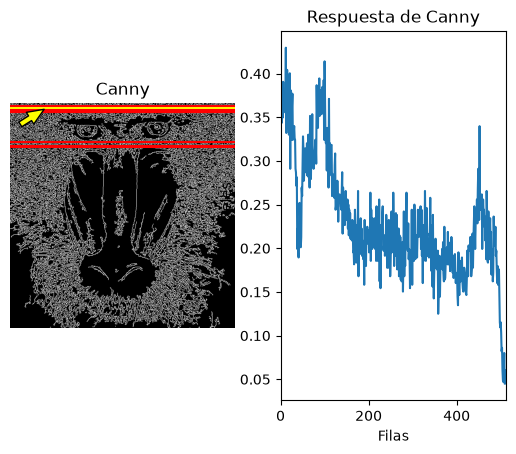

In [17]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de COLUMNAS, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por FILA

rows = row_counts / (255 * canny.shape[1])
fila_max = np.argmax(rows)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

# Flechita para indicar fila con máximo de pixels blancos
plt.annotate(
    '',                      # Texto vacío (solo queremos la flecha)
    xy=(80, 12),             # Coordenadas de la PUNTA de la flecha
    xytext=(20, 50),         # Coordenadas de la COLA de la flecha
    arrowprops=dict(
        facecolor='yellow',  # Color de relleno de la flecha
        edgecolor='black',   # Color del borde
        shrink=0.05,         # Espacio libre en los extremos
        width=4,             # Grosor del cuerpo de la flecha
        headwidth=10         # Ancho de la cabeza de la flecha
    )
)

# Fila con el máximo valor de píxeles blancos
plt.axhline(y=fila_max, color='yellow', linestyle='-')

# Filas con valor del 90% del máximo anterior
for i in range(0,len(rows)):
    if (rows[i] > rows[fila_max] * 0.90) & (i != fila_max):
        print("Fila @ 90%:  ", i, "\tValor: ", rows[i])
        plt.axhline(i, color='red', linestyle='-')
        
plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en y definido por las filas
print(canny.shape[1])
plt.xlim([0, canny.shape[0]])

Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

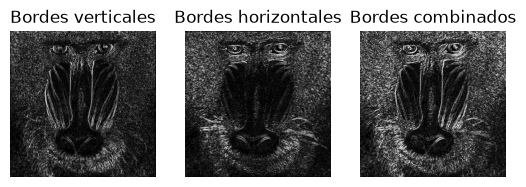

In [24]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

#Muestra ambos resultados
plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Bordes verticales')
#Verticales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Bordes horizontales')
#Horizontales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

Observa que visualizar la imagen resultado de Sobel directamente como escala de grises produce un resultado diferente. Ha sido necesario convertir a datos de tipo byte. La siguiente celda muestra dos variantes de conversión, con OpenCV y numpy, evidenciando alguna diferencia, además de los valores antes y tras escalar a 8 bits

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


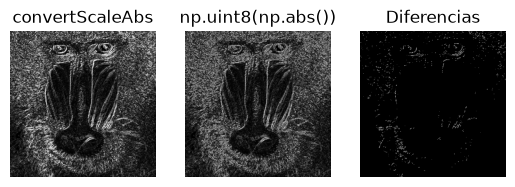

In [ ]:
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

# Conversión a byte con numpy
sobel8np = np.uint8(np.abs(sobel))
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray') 

plt.show()

Umbralizado de una imagen

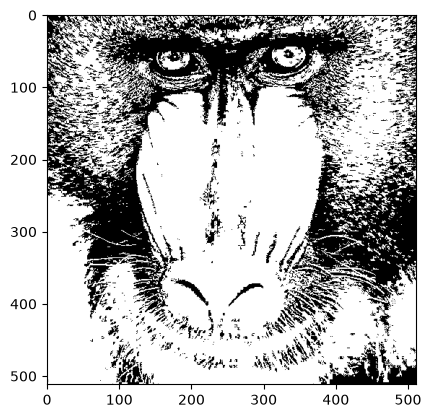

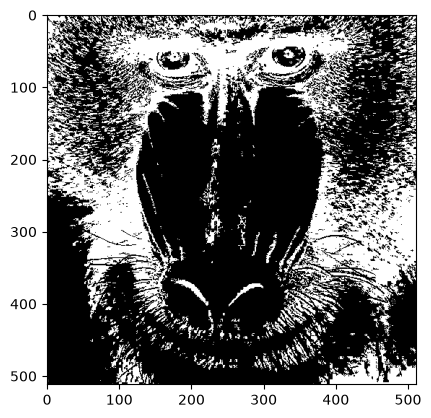

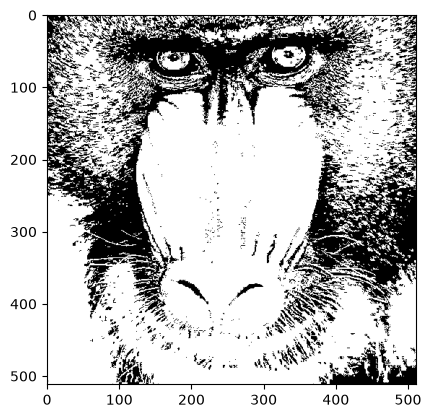

In [ ]:
#Define valor umbral
valorUmbral = 112 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#El umbralizado inverso, los valores menores que el umbral se muestran en blanco
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY_INV)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#Valores en rango determinado por dos umbrales
imagenEnRango = cv2.inRange(gris, 110, 240)
#Muestra resultado
plt.imshow(imagenEnRango, cmap='gray')
plt.show()

El histograma de una imagen aporta información sobre el valor de umbral a elegir para ciertas situaciones

(0.0, 256.0)

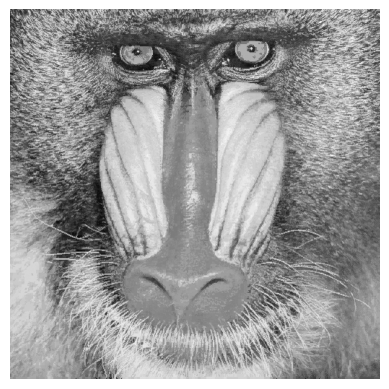

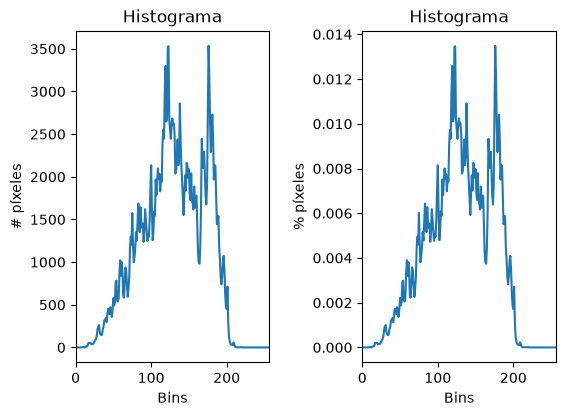

In [ ]:
#Cálculo del histograma de una imagen en escala de grises
hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

plt.figure()
plt.axis("off")
plt.imshow(gris, cmap='gray')

# Histograma sin normalizar
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])

#Normaliza el histograma en base al número de píxeles y lo muestra
hist /= hist.sum()

plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("% píxeles")
plt.tight_layout(pad=3.0) #separación entre plots
plt.plot(hist)
plt.xlim([0, 256])

## Tarea 2
 - Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobel tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

 Fuentes: 
 - Anotaciones en imagen: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html


Canny (100, 200)
Maximo por filas: 220; limite: 198.00
Filas seleccionadas (7), indices desde 0: [6, 12, 15, 20, 21, 88, 100]
Maximo por columnas: 187; limite: 168.30
Columnas seleccionadas (19), indices desde 0: [67, 86, 92, 96, 99, 100, 103, 104, 105, 112, 115, 119, 123, 379, 380, 383, 392, 396, 403]
Pixeles no nulos: 55509 (21.18 %)

Sobel umbralizado (130)
Maximo por filas: 161; limite: 144.90
Filas seleccionadas (7), indices desde 0: [3, 4, 20, 51, 81, 82, 83]
Maximo por columnas: 179; limite: 161.10
Columnas seleccionadas (1), indices desde 0: [288]
Pixeles no nulos: 31199 (11.90 %)


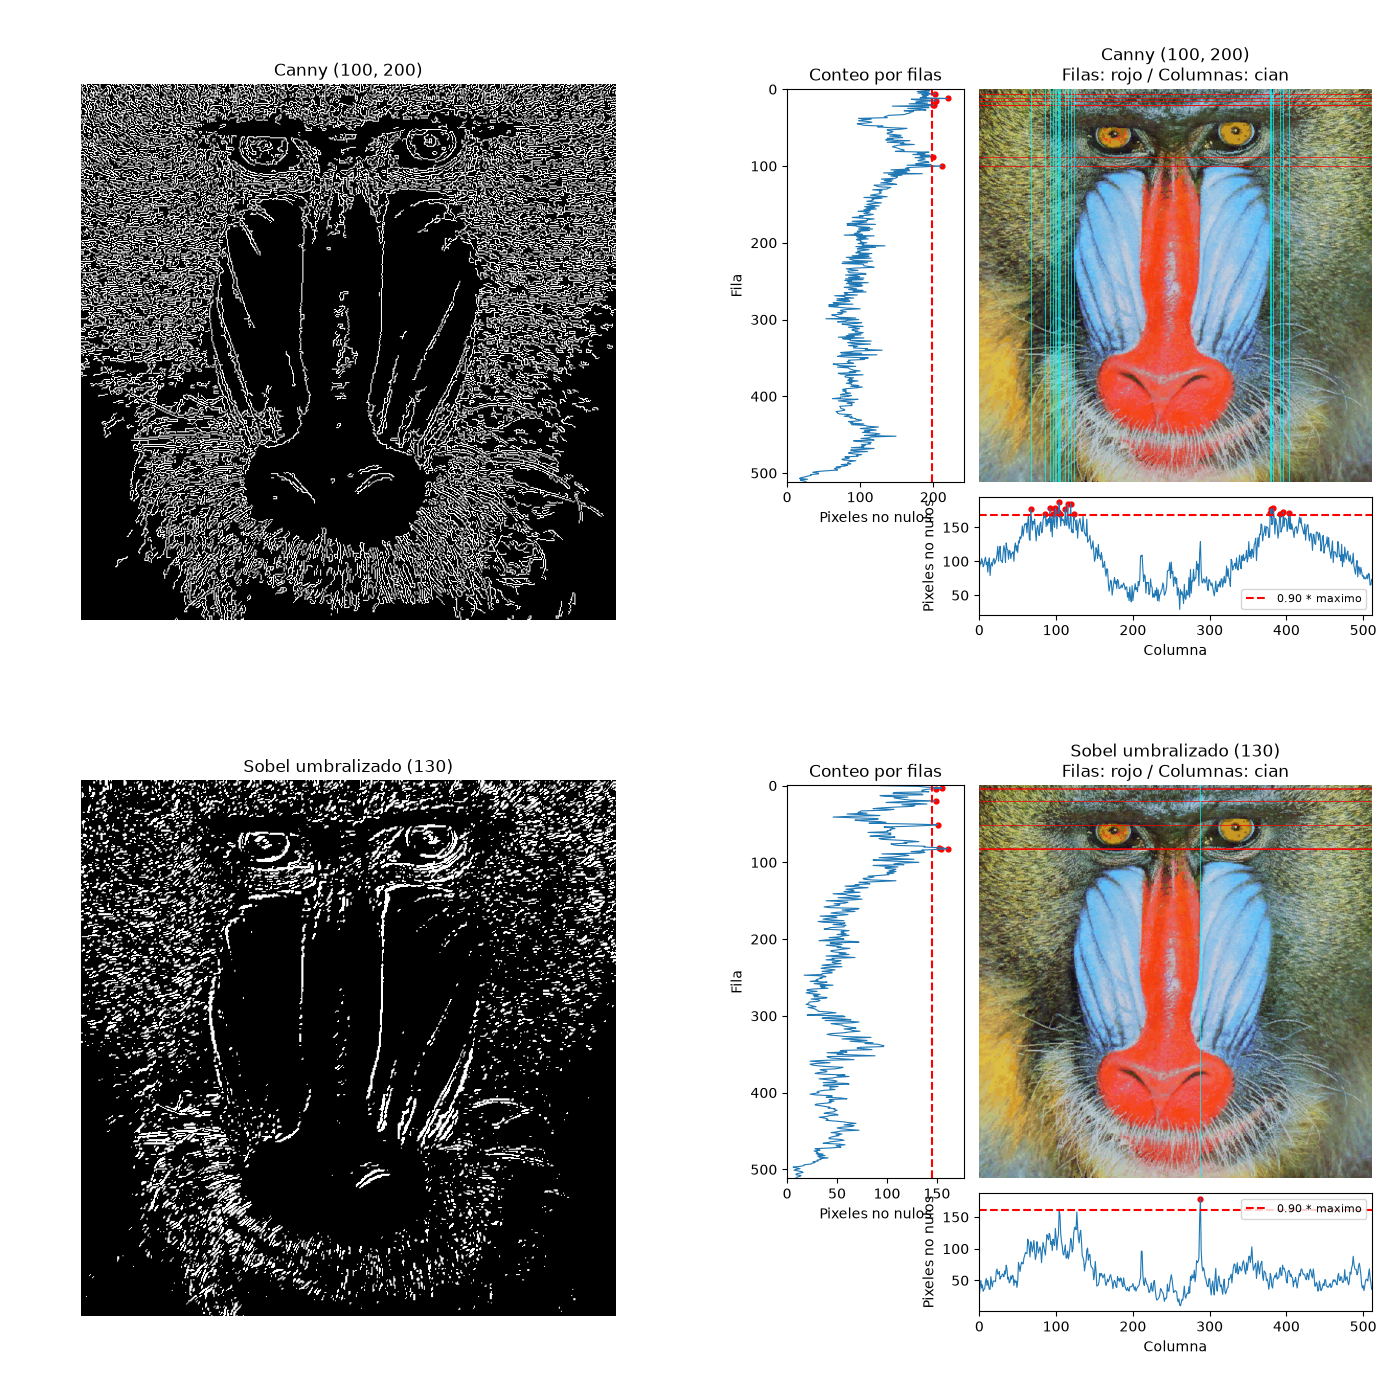

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargo imagen del mandril
mandril = cv2.imread('mandril.jpg')
if mandril is None:
    raise FileNotFoundError('No se encuentra mandril.jpg')
# Guardo en RGB la imagen de OpenCV (la recibo en BGR)
mandril_rgb = cv2.cvtColor(mandril, cv2.COLOR_BGR2RGB)

#Sobel 8 bits
valorUmbralSobel = 130
gris = cv2.cvtColor(mandril, cv2.COLOR_BGR2GRAY)
gauss_gris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(gauss_gris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(gauss_gris, cv2.CV_64F, 0, 1)
sobel8 = cv2.convertScaleAbs(cv2.add(sobelx, sobely))
_, sobel_umbralizado = cv2.threshold(sobel8, valorUmbralSobel, 255, cv2.THRESH_BINARY)
canny = cv2.Canny(gris, 100, 200)

resultados = {}
# El divisor mantiene los conteos alineados con los pixeles del mandril.
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.06, top=0.94,
                    hspace=0.30, wspace=0.25)
for fila_panel, (nombre, bordes) in enumerate([
    ('Canny (100, 200)', canny),
    (f'Sobel umbralizado ({valorUmbralSobel})', sobel_umbralizado),
]):
    # Cuenta real de pixeles no nulos, sin dividir por el ancho o el alto.
    cuentas_filas = np.count_nonzero(bordes, axis=1)
    cuentas_columnas = np.count_nonzero(bordes, axis=0)
    maxfil = int(cuentas_filas.max())
    maxcol = int(cuentas_columnas.max())
    filas = np.flatnonzero(cuentas_filas > 0.90 * maxfil)
    columnas = np.flatnonzero(cuentas_columnas > 0.90 * maxcol)
    resultados[nombre] = dict(maxfil=maxfil, maxcol=maxcol,
        filas=filas, columnas=columnas, total=int(np.count_nonzero(bordes)))
    print(f'\n{nombre}')
    print(f'Maximo por filas: {maxfil}; limite: {0.90 * maxfil:.2f}')
    print(f'Filas seleccionadas ({len(filas)}), indices desde 0: {filas.tolist()}')
    print(f'Maximo por columnas: {maxcol}; limite: {0.90 * maxcol:.2f}')
    print(f'Columnas seleccionadas ({len(columnas)}), indices desde 0: {columnas.tolist()}')
    print(f'Pixeles no nulos: {np.count_nonzero(bordes)} ({100 * np.count_nonzero(bordes) / bordes.size:.2f} %)')

    axes[fila_panel, 0].imshow(bordes, cmap='gray', vmin=0, vmax=255)
    axes[fila_panel, 0].set_title(nombre)
    axes[fila_panel, 0].axis('off')

    ax_imagen = axes[fila_panel, 1]
    ax_imagen.imshow(mandril_rgb)
    for y in filas:
        ax_imagen.axhline(y, color='red', linewidth=0.7, alpha=0.7)
    for x in columnas:
        ax_imagen.axvline(x, color='cyan', linewidth=0.7, alpha=0.7)
    ax_imagen.set_title(f'{nombre}\nFilas: rojo / Columnas: cian')
    ax_imagen.axis('off')

    divisor = make_axes_locatable(ax_imagen)
    ax_filas = divisor.append_axes('left', size='45%', pad=0.15, sharey=ax_imagen)
    ax_columnas = divisor.append_axes('bottom', size='30%', pad=0.15, sharex=ax_imagen)

    # Giro de 90 grados a la derecha: conteo en X y filas en Y, de arriba abajo.
    ax_filas.plot(cuentas_filas, np.arange(len(cuentas_filas)), linewidth=0.8)
    ax_filas.axvline(0.90 * maxfil, color='red', linestyle='--')
    ax_filas.scatter(cuentas_filas[filas], filas, color='red', s=12)
    ax_filas.set(xlabel='Pixeles no nulos', ylabel='Fila',
                 title='Conteo por filas', xlim=(0, max(1, maxfil * 1.1)))
    ax_filas.set_ylim(bordes.shape[0] - 0.5, -0.5)

    ax_columnas.plot(cuentas_columnas, linewidth=0.8)
    ax_columnas.axhline(0.90 * maxcol, color='red', linestyle='--',
                       label='0.90 * maximo')
    ax_columnas.scatter(columnas, cuentas_columnas[columnas], color='red', s=12)
    ax_columnas.set(xlabel='Columna', ylabel='Pixeles no nulos',
                    xlim=(-0.5, bordes.shape[1] - 0.5))
    ax_columnas.legend(fontsize=8)
plt.show()


### Comparacion de resultados

Se aplica el umbral 130 a **Sobel convertido a 8 bits**, y se compara con Canny (100, 200). Se cuentan pixeles no nulos mediante `np.count_nonzero`: `axis=1` para filas y `axis=0` para columnas. La seleccion utiliza **> 0.90 * maximo**, con indices desde cero. Las lineas rojas marcan filas y las cian columnas sobre el original.

| Metodo | Maximo por fila | Maximo por columna | Filas seleccionadas | Columnas seleccionadas | Pixeles no nulos |
|---|---:|---:|---:|---:|---:|
| Canny | 220 | 187 | 7 | 19 | 55 509 (21.18 %) |
| Sobel, umbral 130 | 161 | 179 | 7 | 1 | 31199 (11.90 %) |

En esta imagen, Canny presenta contornos mas finos y continuos, y conserva mas detalle del pelo. Sobel umbralizado produce trazos mas gruesos y fragmentados, descartando muchas respuestas debiles con el umbral elegido. Ambos concentran respuestas en zonas de textura y cambios de intensidad, pero las posiciones seleccionadas no coinciden: solo comparten la fila 20 y no comparten columnas. Tener el mismo numero de filas seleccionadas no implica detectar las mismas filas.

Canny incorpora supresion de no maximos e histeresis con dos umbrales; Sobel seguido de un unico umbral no realiza esos pasos. Los numeros dependen de los parametros y del suavizado: aqui se conserva la gaussiana previa de Sobel y la entrada de Canny del ejemplo. No puede concluirse que Sobel siempre detecte menos pixeles.

**Particularidad del ejemplo:** se conserva `sobelx + sobely` antes de `convertScaleAbs`, por lo que derivadas de signo opuesto pueden cancelarse y favorecer unas orientaciones frente a otras. Para representar la magnitud del gradiente sin esa cancelacion se puede usar `cv2.magnitude(sobelx, sobely)` y ajustar el umbral; seria una variante con resultados diferentes.


Diferencia de imágenes

In [ ]:
#Calcula la diferencia entre dos imágenes
#Utiliza la imagen original y la obtenida tras aplicar la gaussiana (creada en la celda dedicada a Sobel)
dif = cv2.absdiff(gris, ggris)

#Visualiza
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 

#Zonas de mayor diferencia tras aplicar umbral
res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
#Visualiza
plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray') 
plt.show()


Webcam y sustracción de fotogramas

In [ ]:
vid = cv2.VideoCapture(0)

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)        
            # Muestra resultado
            cv2.imshow('Diferencia', dif)    
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Webcam y sustracción de modelo del fondo

In [ ]:
vid = cv2.VideoCapture(0)

# Fondo
# Inicializa la sustracción del fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Aplica efecto espejo sobre la entrada
        framem=cv2.flip(frame, 1)
        
        #Con un segundo parámerto se puede definir máscara con zonas a actualizar
        objetos = eliminadorFondo.apply(framem)
        #objetos = eliminadorFondo.apply(framem, objetos, 0)  #No actualiza el fondo
        # Obtiene fondo
        background = eliminadorFondo.getBackgroundImage()

        # Muestra resultado
        cv2.imshow('Fotograma', objetos)
        # Muestra fondo
        cv2.imshow('Fondo', background)
  
   
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

---
